### Matrix & Vector Derivative Formulas (Numerator Layout)

| Expression $f$ | Derivative $\frac{\partial f}{\partial \text{variable}}$ | Description / Context |
| :--- | :--- | :--- |
| $\mathbf{a}^T \mathbf{x}$ | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{a}^T \mathbf{x}) = \mathbf{a}^T$ | Linear vector product |
| $\mathbf{x}^T \mathbf{a}$ | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T \mathbf{a}) = \mathbf{a}^T$ | Linear vector product |
| $\mathbf{A} \mathbf{x}$ | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{A} \mathbf{x}) = \mathbf{A}$ | Matrix-vector product |
| $\mathbf{x}^T \mathbf{A} \mathbf{x}$ | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T \mathbf{A} \mathbf{x}) = \mathbf{x}^T(\mathbf{A} + \mathbf{A}^T)$ | Quadratic form (general) |
| $\mathbf{x}^T \mathbf{A} \mathbf{x}$ *(if $\mathbf{A}$ is symmetric)* | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T \mathbf{A} \mathbf{x}) = 2\mathbf{x}^T \mathbf{A}$ | Quadratic form (symmetric $\mathbf{A}$) |
| $\|\mathbf{x}\|^2 = \mathbf{x}^T \mathbf{x}$ | $\frac{\partial}{\partial \mathbf{x}}(\mathbf{x}^T \mathbf{x}) = 2\mathbf{x}^T$ | Squared L2 norm |
| $\text{Tr}(\mathbf{A}\mathbf{X})$ | $\frac{\partial}{\partial \mathbf{X}}\text{Tr}(\mathbf{A}\mathbf{X}) = \mathbf{A}^T$ | Trace of matrix product |
| $\text{Tr}(\mathbf{X}^T\mathbf{A}\mathbf{X})$ | $\frac{\partial}{\partial \mathbf{X}}\text{Tr}(\mathbf{X}^T\mathbf{A}\mathbf{X}) = \mathbf{X}^T(\mathbf{A} + \mathbf{A}^T)$ | Quadratic form trace |
| $\|\mathbf{Y} - \mathbf{X}\mathbf{W}\|_F^2$ | $\frac{\partial}{\partial \mathbf{W}} = -2\mathbf{X}^T(\mathbf{Y} - \mathbf{X}\mathbf{W})$ | Linear Regression MSE gradient |

# Derivation of Cost Function : J(β)

This document provides a complete symbol breakdown and step-by-step derivation for differentiating the Linear Regression cost function $J(\beta)$ with respect to the parameter vector $\beta$.

### 1. Symbol Representations

| Symbol | Meaning / Description |
| :--- | :--- |
| $J(\beta)$ | **Cost / Loss Function** (Mean Squared Error across all samples) |
| $\beta$ | **Parameter / Weight Vector** (coefficients to be learned) |
| $X$ | **Input Feature Matrix** (data matrix with dimensions $m \times n$) |
| $y$ | **Target / Ground Truth Vector** (actual labels with dimensions $m \times 1$) |
| $\hat{y}$ | **Predicted Output Vector**, defined as $\hat{y} = X\beta$ |
| $m$ | **Sample Size** (total number of data observations) |
| $(\cdot)^T$ | **Matrix / Vector Transpose** operator |
| $S(\beta)$ | **Sum of Squared Errors** $(y - X\beta)^T(y - X\beta)$ prior to $\frac{1}{2m}$ scaling |



### 2. Matrix Identities & Rules

1. **Transpose of Difference:** $(A - B)^T = A^T - B^T$
2. **Transpose of Product:** $(AB)^T = B^T A^T$
3. **Derivative of Linear Vector Form:** $\frac{d}{dx} (A^T x) = A$
4. **Derivative of Quadratic Form:** $\frac{d}{dx} (x^T A x) = 2 Ax$ *(when $A$ is symmetric)*


### 3. Step-by-Step Differentiation

###E **Step 1: Expand the Sum of Squared Residuals $S(\beta)$**

Starting with the vector expression:
$$S(\beta) = (y - X\beta)^T (y - X\beta)$$

Apply transpose rule $(A - B)^T = A^T - B^T$:
$$S(\beta) = (y^T - (X\beta)^T) (y - X\beta)$$

Apply transpose rule $(AB)^T = B^T A^T$:
$$S(\beta) = (y^T - \beta^T X^T) (y - X\beta)$$

Expand by multiplying out the terms:
$$S(\beta) = y^T y - y^T X \beta - \beta^T X^T y + \beta^T X^T X \beta$$

Since $y^T X \beta$ is a scalar (a $1 \times 1$ matrix), it is equal to its transpose:
$$(y^T X \beta)^T = \beta^T X^T y$$

Combining the middle terms yields:
$$S(\beta) = y^T y - 2 y^T X \beta + \beta^T X^T X \beta$$

#### **Step 2: Differentiate $S(\beta)$ with respect to $\beta$**

Take the derivative with respect to $\beta$ term-by-term:
$$\frac{d}{d\beta} S(\beta) = \frac{d}{d\beta} \left( y^T y - 2 y^T X \beta + \beta^T X^T X \beta \right)$$

1. $\frac{d}{d\beta}(y^T y) = 0$ *(constant with respect to $\beta$)*
2. $\frac{d}{d\beta}(2 y^T X \beta) = 2 (y^T X)^T = 2 X^T y$ *(using $\frac{d}{dx} A^T x = A$)*
3. $\frac{d}{d\beta}(\beta^T X^T X \beta) = 2 X^T X \beta$ *(using $\frac{d}{dx} x^T A x = 2Ax$ with $A = X^T X$)*

Putting it together:
$$\frac{d}{d\beta} S(\beta) = 0 - 2 X^T y + 2 X^T X \beta$$

Factor out $2 X^T$:
$$\frac{d}{d\beta} S(\beta) = 2 X^T (X \beta - y)$$

Since $\hat{y} = X\beta$:
$$\frac{d}{d\beta} S(\beta) = 2 X^T (\hat{y} - y)$$



#### **Step 3: Compute the Final Gradient $\frac{d J(\beta)}{d\beta}$**

The cost function $J(\beta)$ includes the constant scaling factor $\frac{1}{2m}$:
$$J(\beta) = \frac{1}{2m} S(\beta)$$

Therefore:
$$\frac{d J(\beta)}{d\beta} = \frac{1}{2m} \cdot \frac{d S(\beta)}{d\beta}$$

$$\frac{d J(\beta)}{d\beta} = \frac{1}{2m} \cdot 2 X^T (\hat{y} - y)$$

$$= \frac{1}{m} X^T (\hat{y} - y)$$

$$\mathbf{= \frac{X^T (\hat{y} - y)}{m}}$$

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 100

# Features
square_feet = np.random.randint(500, 3500, size=n_samples)
# Bedrooms scaled logically with size (1 to 5 bedrooms)
bedrooms = np.clip((square_feet // 600) + np.random.choice([-1, 0, 1], size=n_samples), 1, 5)

# Formula: Price = (120 * sqft) + (15,000 * bedrooms) + 40,000 + noise
noise = np.random.normal(loc=0, scale=20000, size=n_samples)
price = (120 * square_feet) + (15000 * bedrooms) + 40000 + noise

df_house = pd.DataFrame({
    'Square_Feet': square_feet,
    'Bedrooms': bedrooms,
    'Price': price.round(2)
})

print(df_house.head())

# Quick check for outliers in Price
Q1 = df_house['Price'].quantile(0.25)
Q3 = df_house['Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_house[(df_house['Price'] < (Q1 - 1.5 * IQR)) | (df_house['Price'] > (Q3 + 1.5 * IQR))]
print(f"\nNumber of outliers found: {len(outliers)}")

   Square_Feet  Bedrooms      Price
0         1360         3  234945.23
1         1794         3  297350.54
2         1630         3  263679.66
3         1595         1  229950.21
4         2138         4  378294.54

Number of outliers found: 0


In [2]:
# Prepare the train set :
import statsmodels.api as sm

input_feature = df_house[["Square_Feet","Bedrooms"]] 
# Feature Scaling (Z-standardisation) 
input_feature = (input_feature - input_feature.mean())/input_feature.std()
input_feature = sm.add_constant(input_feature)

X = input_feature.to_numpy()
Y = ((df_house["Price"] - df_house["Price"].mean())/df_house["Price"].std()).to_numpy()

In [3]:
alpha = 0.01 # learning rate
m = len(X) # number of rows
beta = np.zeros(3)
# beta.T.shape

In [4]:
# Epoch 1
print("=== Epoch 1 ===") 

y_pred = X @ beta    # y = mx + c
print(f"Prediction : \n{y_pred[:5]}")

error = Y - y_pred
print(f"Errors : \n{error[:5]}")

gradient = (X.T @ (y_pred - Y))/m
print(f"Gradient :\n{gradient[:5]}")

beta = beta - alpha*gradient
print(f"Updated beta : \n{beta[:5]}")

y_pred = X @ beta
print(f"Predictions :\n{y_pred[:5]}")

=== Epoch 1 ===
Prediction : 
[0. 0. 0. 0. 0.]
Errors : 
[-0.74254659 -0.24464962 -0.51329068 -0.78239905  0.40115717]
Gradient :
[ 1.95399252e-16 -9.73537318e-01 -8.78100488e-01]
Updated beta : 
[-1.95399252e-18  9.73537318e-03  8.78100488e-03]
Predictions :
[-0.00737403 -0.00243334 -0.00430033 -0.01699464  0.00763072]


In [5]:
# Epoch 2
print("=== Epoch 2 ===") 

y_pred = X @ beta    # y = mx + c
print(f"Prediction : \n{y_pred[:5]}")

error = Y - y_pred
print(f"Errors : \n{error[:5]}")

gradient = (X.T @ (y_pred - Y))/m
print(f"Gradient :\n{gradient[:5]}")

beta = beta - alpha*gradient
print(f"Updated beta : \n{beta[:5]}")

y_pred = X @ beta
print(f"Predictions :\n{y_pred[:5]}")

=== Epoch 2 ===
Prediction : 
[-0.00737403 -0.00243334 -0.00430033 -0.01699464  0.00763072]
Errors : 
[-0.73517255 -0.24221628 -0.50899036 -0.76540441  0.39352645]
Gradient :
[ 1.33226763e-16 -9.56447138e-01 -8.61145190e-01]
Updated beta : 
[-3.28626015e-18  1.92998446e-02  1.73924568e-02]
Predictions :
[-0.01461883 -0.00482418 -0.00852538 -0.03366959  0.01511649]


In [6]:
for epoch in range(3,1501):
    # Epoch 1
    print(f"=== Epoch {epoch} ===") 

    y_pred = X @ beta    # y = mx + c
    # print(f"Prediction : \n{y_pred[:5]}")

    error = Y - y_pred
    # print(f"Errors : \n{error[:5]}")

    gradient = (X.T @ (y_pred - Y))/m
    # print(f"Gradient :\n{gradient[:5]}")

    beta = beta - alpha*gradient
    # print(f"Updated beta : \n{beta[:5]}")

    y_pred = X @ beta
    # print(f"Predictions :\n{y_pred[:5]}")

=== Epoch 3 ===
=== Epoch 4 ===
=== Epoch 5 ===
=== Epoch 6 ===
=== Epoch 7 ===
=== Epoch 8 ===
=== Epoch 9 ===
=== Epoch 10 ===
=== Epoch 11 ===
=== Epoch 12 ===
=== Epoch 13 ===
=== Epoch 14 ===
=== Epoch 15 ===
=== Epoch 16 ===
=== Epoch 17 ===
=== Epoch 18 ===
=== Epoch 19 ===
=== Epoch 20 ===
=== Epoch 21 ===
=== Epoch 22 ===
=== Epoch 23 ===
=== Epoch 24 ===
=== Epoch 25 ===
=== Epoch 26 ===
=== Epoch 27 ===
=== Epoch 28 ===
=== Epoch 29 ===
=== Epoch 30 ===
=== Epoch 31 ===
=== Epoch 32 ===
=== Epoch 33 ===
=== Epoch 34 ===
=== Epoch 35 ===
=== Epoch 36 ===
=== Epoch 37 ===
=== Epoch 38 ===
=== Epoch 39 ===
=== Epoch 40 ===
=== Epoch 41 ===
=== Epoch 42 ===
=== Epoch 43 ===
=== Epoch 44 ===
=== Epoch 45 ===
=== Epoch 46 ===
=== Epoch 47 ===
=== Epoch 48 ===
=== Epoch 49 ===
=== Epoch 50 ===
=== Epoch 51 ===
=== Epoch 52 ===
=== Epoch 53 ===
=== Epoch 54 ===
=== Epoch 55 ===
=== Epoch 56 ===
=== Epoch 57 ===
=== Epoch 58 ===
=== Epoch 59 ===
=== Epoch 60 ===
=== Epoch 61 ===
=== 

In [7]:
print(f"Actual : \n{Y[:10]}")
print(f"Predictions : \n{y_pred[:1].flatten()[:10]}")

Actual : 
[-0.74254659 -0.24464962 -0.51329068 -0.78239905  0.40115717  1.01617675
 -1.32386006 -0.28832231 -1.18618698 -0.26890503]
Predictions : 
[-0.61370693]


In [8]:
# Actual vs Predicted, converted back to real dollar prices
predicted_price = y_pred.ravel() * df_house['Price'].std() + df_house['Price'].mean()

comparison = pd.DataFrame({
    'Actual_Price($)': df_house['Price'].values,
    'Predicted_Price($)': predicted_price.round(2)
})
comparison['Error'] = (comparison['Actual_Price($)'] - comparison['Predicted_Price($)']).round(2)

print(comparison.head(10))

   Actual_Price($)  Predicted_Price($)     Error
0        234945.23           251093.71 -16148.48
1        297350.54           302024.93  -4674.39
2        263679.66           282779.03 -19099.37
3        229950.21           242453.92 -12503.71
4        378294.54           360503.26  17791.28
5        455379.74           440926.61  14453.13
6        162084.68           168638.85  -6554.17
7        291876.70           295453.16  -3576.46
8        179340.32           152678.83  26661.49
9        294310.42           324087.31 -29776.89


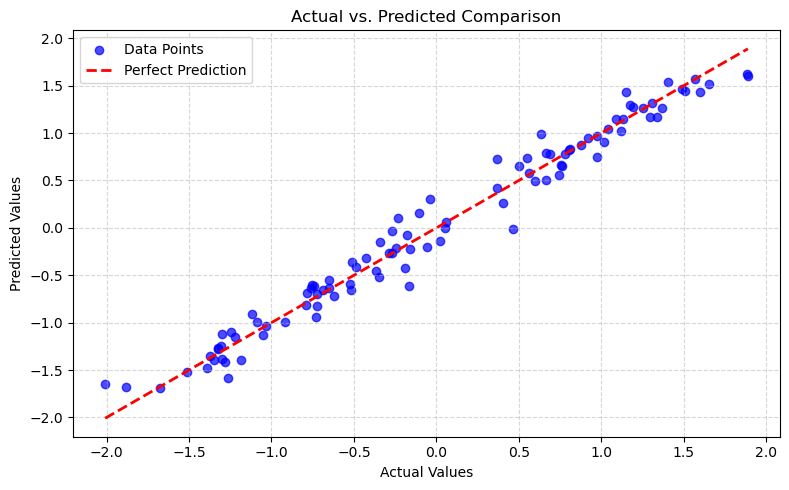

In [9]:
import matplotlib.pyplot as plt

actual = Y
predictions_flat = y_pred.flatten()
plt.figure(figsize=(8, 5))

# Create a scatter plot of actual vs predicted
plt.scatter(actual, predictions_flat, alpha=0.7, color='blue', label='Data Points')

# Draw a red dashed line representing perfect predictions (y = x)
min_val = min(actual.min(), predictions_flat.min())
max_val = max(actual.max(), predictions_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=comparison['Actual_Price($)'], y=comparison['Predicted_Price($)'],
    mode='markers',
    marker=dict(
        size=9, color=comparison['Error'].abs(), colorscale='Reds',
        showscale=True, colorbar=dict(title='|Error| ($)'),
        line=dict(width=0.5, color='black')
    ),
    text=comparison['Error'],
    hovertemplate='Actual: $%{x:,.0f}<br>Predicted: $%{y:,.0f}<br>Error: $%{text:,.0f}<extra></extra>',
    name='Houses'
))

lims = [comparison[['Actual_Price($)', 'Predicted_Price($)']].min().min(),
        comparison[['Actual_Price($)', 'Predicted_Price($)']].max().max()]
fig.add_trace(go.Scatter(
    x=lims, y=lims, mode='lines',
    line=dict(color='gray', dash='dash'),
    name='Perfect fit', hoverinfo='skip'
))

fig.update_layout(
    title='Actual vs Predicted House Price',
    xaxis_title='Actual Price ($)',
    yaxis_title='Predicted Price ($)',
    template='plotly_white'
)

fig.show()

In [11]:
def predict_price(square_feet, bedrooms):
    x = np.array([
        1,
        (square_feet - df_house['Square_Feet'].mean()) /df_house['Square_Feet'].std(),
        (bedrooms - df_house['Bedrooms'].mean()) /df_house['Bedrooms'].std()
    ])
    # print(x.shape)
    price_std_pred = x @ beta.ravel()
    return price_std_pred * df_house['Price'].std() + df_house['Price'].mean()

sqft_input = float(input("Square feet: "))
bed_input = float(input("Bedrooms: "))
print(f"Predicted price: ${predict_price(sqft_input, bed_input):,.2f}")

Predicted price: $208,846.61


In [12]:
beta.ravel()

array([-1.94247396e-16,  8.00694138e-01,  2.06359561e-01])